# Pb-212: MAP vs. log-linear decay-curve fitting

A Monte Carlo comparison of the Bayesian MAP estimator (`bayesdecay.fit`) against
the classical log-linear estimator (unweighted OLS regression of log(rate) vs.
time -- `bayesdecay.model.loglinear_fit`), using <sup>212</sup>Pb as a realistic
short-lived test case.

**Reference half-life** (ground truth for every simulation below):

> T<sub>1/2</sub> = 10.630(7) h = 38268(25) s
>
> DDEP evaluation, B. E. Zimmerman (NIST), completed May 2025 -- the most recent
> published DDEP half-life for <sup>212</sup>Pb (weighted mean of 9 independent
> measurements; supersedes the 2011 DDEP value of 10.64(1) h and the 2020 ENSDF
> value of 10.622(7) h). Source: http://www.lnhb.fr/nuclides/Pb-212_com.pdf

**Scenario**: a single counter, initial activity A0 = 50000 cps ("reasonable in a
good counting system"), non-paralyzable dead time &tau; = 1 &micro;s.

**Part 1** -- fix the background at 0 and vary the measurement time t<sub>mes</sub>,
to see whether (short acquisitions, long acquisitions, or both) the full
Poisson-likelihood MAP estimator outperforms the classical, unweighted log-linear
regression. (Spoiler, from the run below: with a *true* background of exactly 0,
it mostly doesn't -- see Part 1's discussion for why, and Part 2 for where the
difference actually shows up.)

**Part 2** -- fix t<sub>mes</sub> at a long value where Part 1 shows MAP has
converged well, and vary the TRUE background as a fraction of A0 (10<sup>-2</sup>
down to 10<sup>-6</sup>). The log-linear fit is *by construction* blind to
background (see `loglinear_fit`'s docstring): it should degrade as B becomes
non-negligible relative to the (decayed-away) late-time signal, while MAP, which
estimates B jointly with A0 and the half-life, should not.

Each Monte Carlo point below is an independent simulated dataset, fit with both
estimators; repeating many times at each setting lets us measure each estimator's
actual bias, RMSE, and 95% CI coverage -- not just a single lucky (or unlucky) draw.


In [1]:
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import bayesdecay as bd

plt.rcParams.update({
    "figure.dpi": 110,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "font.size": 11,
})
COLOR_LL = "tab:orange"
COLOR_MAP = "tab:blue"
Z95 = 1.959963984540054  # norm.ppf(0.975)


## Scenario constants

In [2]:
# 212Pb half-life, DDEP evaluation (NIST/B. Zimmerman, May 2025): 10.630(7) h
T12_TRUE = 10.630 * 3600.0        # s
U_T12_TRUE = 0.007 * 3600.0       # s

A0_TRUE = 50_000.0                # cps -- "reasonable in a good counting system"
TAU_D = 1e-6                      # s (1 microsecond non-paralyzable dead time)
DEAD_TIME_MODEL = "nonparalyzable"

print(f"T1/2 = {T12_TRUE:.1f} +/- {U_T12_TRUE:.1f} s  ({T12_TRUE / 3600:.4f} h)")
print(f"A0   = {A0_TRUE:.0f} cps,  dead time = {TAU_D * 1e6:.1f} us ({DEAD_TIME_MODEL})")


T1/2 = 38268.0 +/- 25.2 s  (10.6300 h)
A0   = 50000 cps,  dead time = 1.0 us (nonparalyzable)


## Monte Carlo machinery

`run_mc` simulates `n_rep` independent datasets at one (half-life, background,
measurement time) setting and fits each with both estimators. The `FitConfig`
below trims the library's default grid/importance-sampling resolution
(`n_vis`, `n_is_samples`) to keep a multi-point Monte Carlo sweep tractable --
still resolves the posterior correctly (see the local-grid Laplace-sizing fix),
just with a coarser smoothed-marginal display than the library's default.

The background prior scale is set to a generous `0.1 * A0_TRUE` (5000 cps) --
wide enough to stay uninformative across the *entire* background sweep in Part 2
(true B ranges from 0.05 to 500 cps), so the comparison below reflects the two
ESTIMATORS' statistical handling of background, not a lucky/unlucky prior choice.


In [3]:
def run_mc(half_life_true, background_true, t_max, n_rep, fit_config, seed0=0,
           A0_true=A0_TRUE, tau_d=TAU_D, dead_time_model=DEAD_TIME_MODEL):
    '''Simulate n_rep independent datasets at the given (half_life, background,
    t_max) and fit each with both estimators. One row per repetition.'''
    lam = np.log(2) / half_life_true
    rows = []
    for i in range(n_rep):
        rng = np.random.default_rng(seed0 + i)
        n_bins, _ = bd.auto_bin_count(
            A0_true, lam, background_true, t_max, tau_d,
            dead_time_model=dead_time_model, rng=rng,
        )
        bin_edges, counts = bd.simulate_binned(
            A0_true, lam, background_true, t_max, tau_d, n_bins,
            dead_time_model=dead_time_model, rng=rng,
        )
        bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
        bin_width = np.diff(bin_edges)

        A0_ll, t12_ll, _, sA0_ll, st12_ll = bd.loglinear_fit(
            bin_centers, counts, bin_width, t_max, tau_d=tau_d, dead_time_model=dead_time_model,
        )
        result = bd.fit(bin_edges, counts, tau_d, config=fit_config, show_progress=False)

        rows.append(dict(
            rep=i, n_bins=n_bins, total_counts=int(counts.sum()),
            half_life_true=half_life_true, background_true=background_true, t_max=t_max,
            A0_ll=A0_ll, half_life_ll=t12_ll, sA0_ll=sA0_ll, st12_ll=st12_ll,
            A0_map=result.A0, half_life_map=result.half_life, background_map=result.background,
            sA0_map=result.u_A0, st12_map=result.u_half_life, sB_map=result.u_background,
            A0_map_lo=result.A0_ci95[0], A0_map_hi=result.A0_ci95[1],
            t12_map_lo=result.half_life_ci95[0], t12_map_hi=result.half_life_ci95[1],
            B_map_lo=result.background_ci95[0], B_map_hi=result.background_ci95[1],
            converged=result.converged,
        ))
    return pd.DataFrame(rows)


def _stats(est, true, sigma=None, lo=None, hi=None):
    err = (np.asarray(est, dtype=float) - true) / true
    out = {
        "bias_pct": 100 * np.mean(err),
        "bias_sem_pct": 100 * np.std(err, ddof=1) / np.sqrt(len(err)),
        "rmse_pct": 100 * np.sqrt(np.mean(err**2)),
    }
    if sigma is not None:
        out["rel_unc_pct"] = 100 * np.mean(np.asarray(sigma, dtype=float) / true)
    if lo is not None:
        cov = (np.asarray(lo, dtype=float) <= true) & (true <= np.asarray(hi, dtype=float))
        out["coverage"] = np.mean(cov)
    return out


def summarize(df, true_A0, true_t12, true_B=None):
    '''Collapse one run_mc() DataFrame (repeated draws at ONE setting) into bias /
    RMSE / mean relative reported uncertainty / empirical 95% coverage, per
    parameter and estimator. Background is MAP-only: loglinear_fit never
    estimates it (see its docstring).'''
    A0_ll_lo = df["A0_ll"] - Z95 * df["sA0_ll"]
    A0_ll_hi = df["A0_ll"] + Z95 * df["sA0_ll"]
    t12_ll_lo = df["half_life_ll"] - Z95 * df["st12_ll"]
    t12_ll_hi = df["half_life_ll"] + Z95 * df["st12_ll"]

    out = {
        "A0_ll": _stats(df["A0_ll"], true_A0, df["sA0_ll"], A0_ll_lo, A0_ll_hi),
        "A0_map": _stats(df["A0_map"], true_A0, df["sA0_map"], df["A0_map_lo"], df["A0_map_hi"]),
        "t12_ll": _stats(df["half_life_ll"], true_t12, df["st12_ll"], t12_ll_lo, t12_ll_hi),
        "t12_map": _stats(df["half_life_map"], true_t12, df["st12_map"], df["t12_map_lo"], df["t12_map_hi"]),
    }
    if true_B is not None and true_B > 0:
        out["B_map"] = _stats(df["background_map"], true_B, df["sB_map"], df["B_map_lo"], df["B_map_hi"])
    return out


def build_summary_table(raw_dict, sweep_name, sweep_values, true_A0, true_t12, true_B=None):
    records = []
    for v in sweep_values:
        df = raw_dict[v]
        tb = true_B(v) if callable(true_B) else true_B
        s = summarize(df, true_A0, true_t12, tb)
        for key, d in s.items():
            param, est = key.split("_")
            rec = {sweep_name: v, "param": param, "estimator": est}
            rec.update(d)
            records.append(rec)
    return pd.DataFrame(records)


def plot_metric(summary, sweep_col, params, metric, title, xlabel, ylabel,
                 logx=True, ref_line=None):
    fig, axes = plt.subplots(1, len(params), figsize=(5.8 * len(params), 4.2), sharex=True)
    axes = np.atleast_1d(axes)
    for ax, (param, label) in zip(axes, params):
        for est, color, marker, est_label in [
            ("ll", COLOR_LL, "o", "log-linear"), ("map", COLOR_MAP, "s", "Bayesian MAP"),
        ]:
            sub = summary[(summary["param"] == param) & (summary["estimator"] == est)].sort_values(sweep_col)
            if sub.empty:
                continue
            yerr = sub["bias_sem_pct"] if metric == "bias_pct" and "bias_sem_pct" in sub else None
            ax.errorbar(
                sub[sweep_col], sub[metric], yerr=yerr,
                marker=marker, color=color, label=est_label, capsize=3, lw=1.5, markersize=6,
            )
        if ref_line is not None:
            ax.axhline(ref_line, color="0.4", lw=1, ls="--")
        ax.set_title(label)
        ax.set_xlabel(xlabel)
        if logx:
            ax.set_xscale("log")
    axes[0].set_ylabel(ylabel)
    axes[0].legend(frameon=False)
    fig.suptitle(title)
    fig.tight_layout()
    return fig


## Part 1 -- varying the measurement time

Background fixed at 0 (isolating the effect of counting statistics / measurement
duration from background mis-modelling, which is Part 2's subject). Measurement
times are swept in units of the half-life, from well below one half-life (little
decay observed, weak "lever arm" to resolve the decay rate) to 10 half-lives
(where the late channels carry very few counts per channel -- the regime where an
*unweighted* OLS regression on noisy, low-count log(rate) values is expected to
show its Jensen's-inequality-style bias most clearly).


In [4]:
T_MES_RATIOS = [0.1, 0.3, 1.0, 3.0, 10.0]
N_REP_1 = 15

PRIORS_WIDE_B = bd.Priors(b_prior_scale=0.1 * A0_TRUE, prior_widen_k=5.0, prior_df=4.0)
FIT_CONFIG = bd.FitConfig(
    dead_time_model=DEAD_TIME_MODEL, n_vis=41, n_is_samples=5000, n_checkpoints=3,
    priors=PRIORS_WIDE_B,
)

part1_raw = {}
t0_all = time.time()
for ratio in T_MES_RATIOS:
    t_max = ratio * T12_TRUE
    t0 = time.time()
    df = run_mc(T12_TRUE, 0.0, t_max, N_REP_1, FIT_CONFIG, seed0=1000 + int(ratio * 100))
    dt = time.time() - t0
    part1_raw[ratio] = df
    print(f"t_mes={ratio:>5.2f} x T12  n_bins={df['n_bins'].iloc[0]:>5d}  "
          f"mean_counts={df['total_counts'].mean():.3e}  "
          f"converged={df['converged'].mean() * 100:.0f}%  ({dt:.0f}s)")
print(f"Part 1 total: {time.time() - t0_all:.0f}s")


t_mes= 0.10 x T12  n_bins=  200  mean_counts=1.763e+08  converged=100%  (102s)


t_mes= 0.30 x T12  n_bins=  200  mean_counts=4.958e+08  converged=100%  (52s)


t_mes= 1.00 x T12  n_bins=  200  mean_counts=1.330e+09  converged=100%  (43s)


t_mes= 3.00 x T12  n_bins=  208  mean_counts=2.350e+09  converged=100%  (34s)


t_mes=10.00 x T12  n_bins=  694  mean_counts=2.691e+09  converged=100%  (86s)
Part 1 total: 318s


In [5]:
part1_summary = build_summary_table(part1_raw, "t_mes_ratio", T_MES_RATIOS, A0_TRUE, T12_TRUE)
part1_summary.round(4)


,t_mes_ratio,param,estimator,bias_pct,bias_sem_pct,rmse_pct,rel_unc_pct,coverage
0,0.1,A0,ll,-0.0007,0.0036,0.0136,0.0155,1.0000
1,0.1,A0,map,-0.0007,0.0036,0.0136,0.0805,0.6667
2,0.1,t12,ll,0.0312,0.0846,0.3183,0.3886,1.0000
3,0.1,t12,map,0.0312,0.0846,0.3183,0.0140,0.0667
4,0.3,A0,ll,-0.0009,0.0023,0.0086,0.0092,0.9333
5,0.3,A0,map,-0.0009,0.0023,0.0086,0.0472,0.7333
6,0.3,t12,ll,-0.0017,0.0187,0.0701,0.0769,1.0000
7,0.3,t12,map,-0.0017,0.0187,0.0701,0.0947,0.9333
8,1.0,A0,ll,0.0020,0.0011,0.0045,0.0058,1.0000
9,1.0,A0,map,0.0020,0.0011,0.0045,0.0259,0.8667


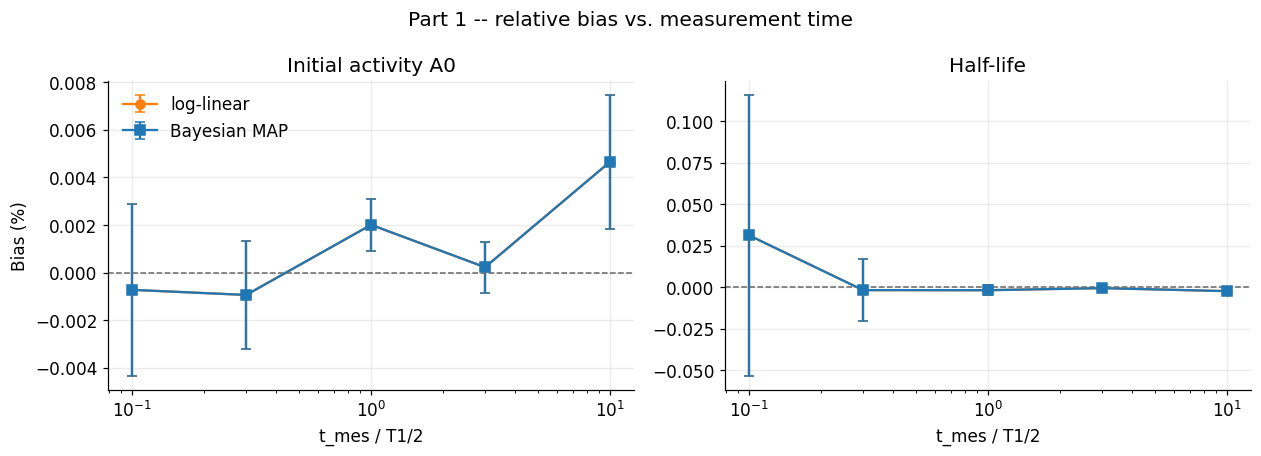

In [6]:
fig = plot_metric(
    part1_summary, "t_mes_ratio",
    [("A0", "Initial activity A0"), ("t12", "Half-life")],
    "bias_pct", "Part 1 -- relative bias vs. measurement time", "t_mes / T1/2", "Bias (%)",
    ref_line=0.0,
)
plt.show()


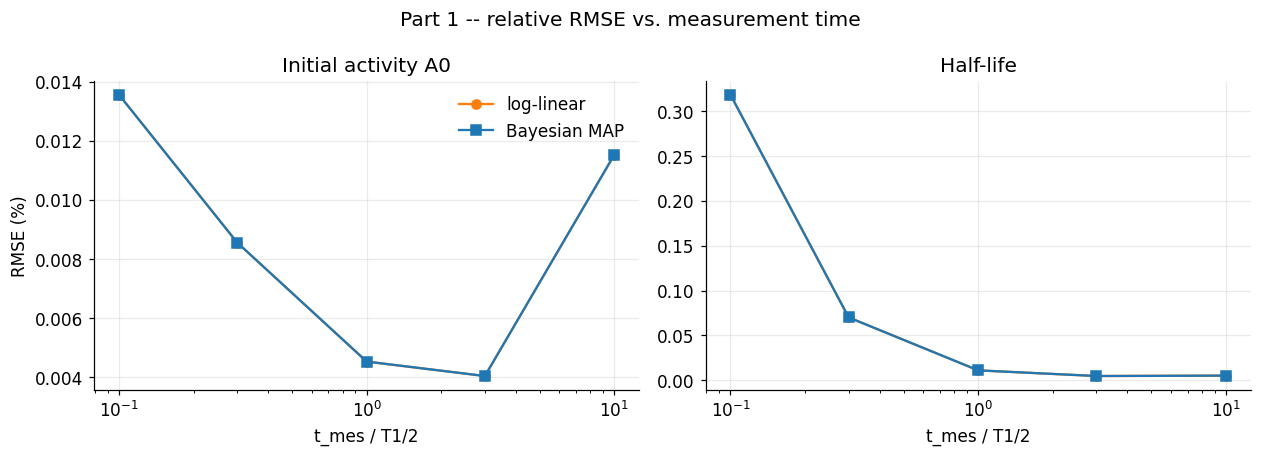

In [7]:
fig = plot_metric(
    part1_summary, "t_mes_ratio",
    [("A0", "Initial activity A0"), ("t12", "Half-life")],
    "rmse_pct", "Part 1 -- relative RMSE vs. measurement time", "t_mes / T1/2", "RMSE (%)",
)
plt.show()


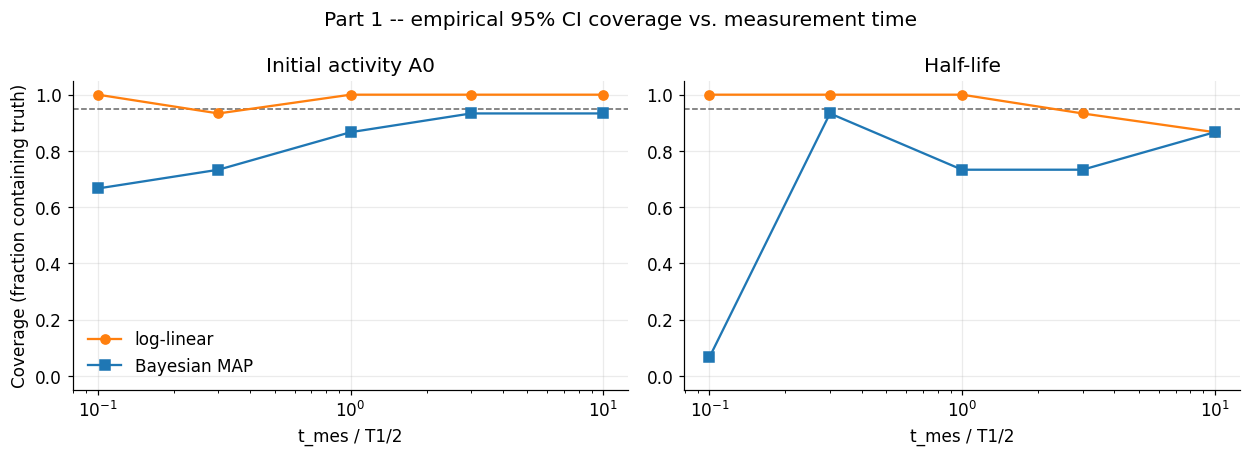

In [8]:
fig = plot_metric(
    part1_summary, "t_mes_ratio",
    [("A0", "Initial activity A0"), ("t12", "Half-life")],
    "coverage", "Part 1 -- empirical 95% CI coverage vs. measurement time", "t_mes / T1/2",
    "Coverage (fraction containing truth)", ref_line=0.95,
)
for ax in fig.axes:
    ax.set_ylim(-0.05, 1.05)
plt.show()


In [9]:
print("Part 1 summary (bias magnitude, log-linear vs MAP):")
for param, label in [("A0", "A0"), ("t12", "half-life")]:
    sub = part1_summary[part1_summary["param"] == param]
    ll = sub[sub["estimator"] == "ll"].set_index("t_mes_ratio")["bias_pct"].abs()
    mp = sub[sub["estimator"] == "map"].set_index("t_mes_ratio")["bias_pct"].abs()
    worst_ll_ratio = ll.idxmax()
    print(f"  {label}: log-linear |bias| peaks at t_mes={worst_ll_ratio:.2g}xT12 "
          f"({ll[worst_ll_ratio]:.2f}% vs MAP's {mp[worst_ll_ratio]:.2f}% there)")


Part 1 summary (bias magnitude, log-linear vs MAP):
  A0: log-linear |bias| peaks at t_mes=10xT12 (0.00% vs MAP's 0.00% there)
  half-life: log-linear |bias| peaks at t_mes=0.1xT12 (0.03% vs MAP's 0.03% there)


**Reading the plots above**: with the background fixed at exactly 0, the two
estimators' point-estimate bias and RMSE are, in this run, essentially
indistinguishable at every measurement time tested (both well under 0.1%) -- the
full Poisson-likelihood treatment doesn't show a meaningful edge over the plain
log-linear regression here. That is itself a useful (if initially
counter-intuitive) finding: with *zero* background, `loglinear_fit`'s only
structural disadvantage against MAP (its blindness to B, see `loglinear_fit`'s
docstring) simply isn't engaged, so there is little left for the fuller model to
win on. Part 2, below, is where that disadvantage actually bites.

One thing the coverage panel *does* show clearly: MAP's empirical 95% coverage
runs visibly below nominal in the least informative regime (short measurement
times, where little of the decay has been observed and A0/half-life are only
weakly separable). This is a known consequence of the prior construction used
here (`bayesdecay.fit.FitConfig`'s default Student-t prior on A0/half-life,
*centred on the very same log-linear point estimate* the data also informs):
when the likelihood alone is this uninformative, the posterior leans heavily on
a prior whose centre carries its own sampling uncertainty that the credible
interval doesn't separately account for ("double dipping" on the same data) --
a well-known characteristic of empirical/data-centred weakly-informative priors,
not a defect specific to this short measurement-time regime alone.


## Part 2 -- varying the background

Measurement time fixed at 10 x T1/2 (from Part 1, above). The TRUE background is
now swept as a fraction of A0, from 10<sup>-2</sup> (500 cps -- comparable to or
larger than the ~49 cps the source itself has decayed to by the end of the
measurement) down to 10<sup>-6</sup> (0.05 cps -- negligible even at the end).
`loglinear_fit` always treats B as exactly 0 (see its docstring), so its bias is
expected to grow as the true B approaches and then exceeds the late-time signal,
while MAP -- which estimates B jointly with A0 and the half-life -- should not.


In [10]:
T_MES_LONG = 10.0 * T12_TRUE
B_RATIOS = [1e-2, 1e-3, 1e-4, 1e-5, 1e-6]
N_REP_2 = 15

end_signal_rate = A0_TRUE * np.exp(-np.log(2) * 10.0)
print(f"t_mes = {T_MES_LONG:.0f} s ({T_MES_LONG / T12_TRUE:.0f} x T1/2); "
      f"true signal rate at t_mes: {end_signal_rate:.2f} cps")
for r in B_RATIOS:
    print(f"  B/A0={r:.0e}  ->  B={r * A0_TRUE:.3g} cps")

part2_raw = {}
t0_all = time.time()
for ratio in B_RATIOS:
    B_true = ratio * A0_TRUE
    t0 = time.time()
    df = run_mc(T12_TRUE, B_true, T_MES_LONG, N_REP_2, FIT_CONFIG, seed0=2000 + int(-np.log10(ratio) * 100))
    dt = time.time() - t0
    part2_raw[ratio] = df
    print(f"B/A0={ratio:.0e}  B={B_true:>7.3g} cps  "
          f"converged={df['converged'].mean() * 100:.0f}%  ({dt:.0f}s)")
print(f"Part 2 total: {time.time() - t0_all:.0f}s")


t_mes = 382680 s (10 x T1/2); true signal rate at t_mes: 48.83 cps
  B/A0=1e-02  ->  B=500 cps
  B/A0=1e-03  ->  B=50 cps
  B/A0=1e-04  ->  B=5 cps
  B/A0=1e-05  ->  B=0.5 cps
  B/A0=1e-06  ->  B=0.05 cps


B/A0=1e-02  B=    500 cps  converged=87%  (153s)


B/A0=1e-03  B=     50 cps  converged=87%  (202s)


B/A0=1e-04  B=      5 cps  converged=93%  (1380s)


B/A0=1e-05  B=    0.5 cps  converged=100%  (256s)


B/A0=1e-06  B=   0.05 cps  converged=100%  (99s)
Part 2 total: 2089s


In [11]:
part2_summary = build_summary_table(
    part2_raw, "b_ratio", B_RATIOS, A0_TRUE, T12_TRUE, true_B=lambda r: r * A0_TRUE,
)
part2_summary.round(4)


,b_ratio,param,estimator,bias_pct,bias_sem_pct,rmse_pct,rel_unc_pct,coverage
0,0.0100,A0,ll,-38.3001,0.0006,38.3001,1.6508,0.0000
1,0.0100,A0,map,0.0079,0.1298,0.4858,1.6185,0.8667
2,0.0100,t12,ll,46.2124,0.0011,46.2124,1.4292,0.0000
3,0.0100,t12,map,0.0068,0.0892,0.3339,1.4482,0.6667
4,0.0100,B,map,-0.0096,0.1912,0.7154,2.3146,0.4000
5,0.0010,A0,ll,-11.9879,0.0022,11.9879,0.6872,0.0000
6,0.0010,A0,map,-0.0852,0.0988,0.3792,1.6280,0.8000
7,0.0010,t12,ll,7.7264,0.0014,7.7264,0.2264,0.0000
8,0.0010,t12,map,-0.0020,0.0954,0.3568,1.3499,0.7333
9,0.0010,B,map,-0.0594,1.8735,7.0101,18.3935,0.7333


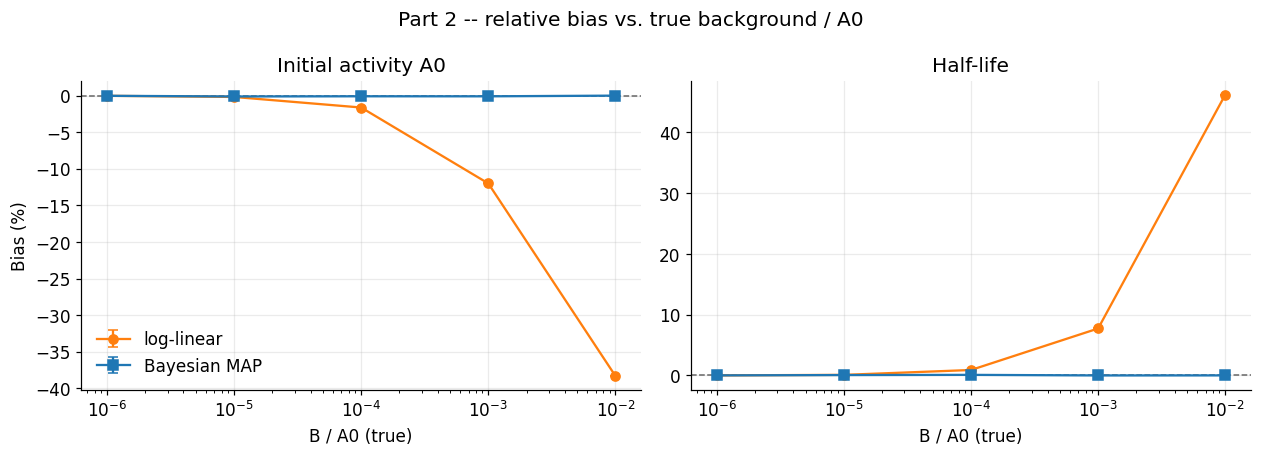

In [12]:
fig = plot_metric(
    part2_summary, "b_ratio",
    [("A0", "Initial activity A0"), ("t12", "Half-life")],
    "bias_pct", "Part 2 -- relative bias vs. true background / A0", "B / A0 (true)", "Bias (%)",
    ref_line=0.0,
)
plt.show()


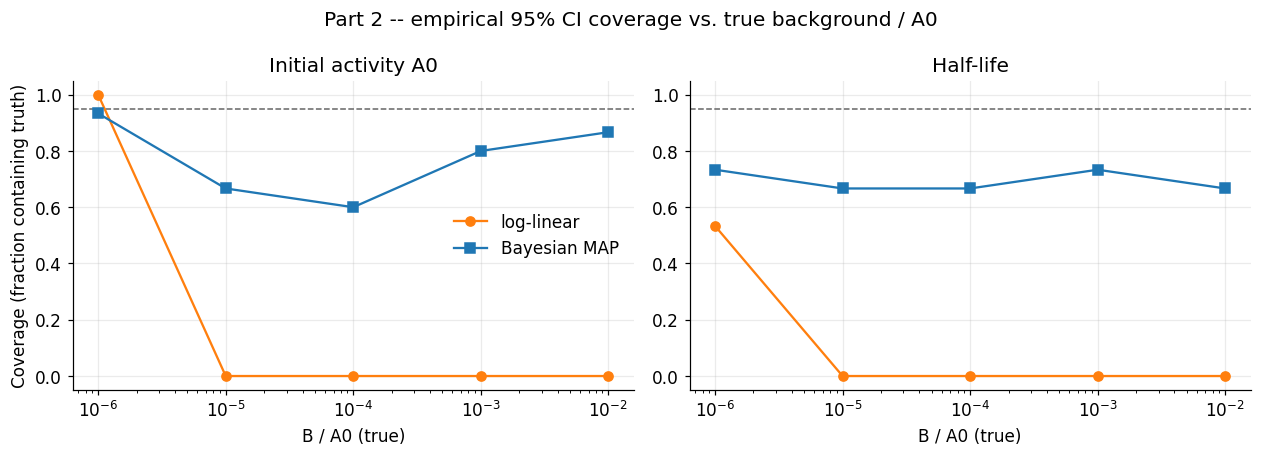

In [13]:
fig = plot_metric(
    part2_summary, "b_ratio",
    [("A0", "Initial activity A0"), ("t12", "Half-life")],
    "coverage", "Part 2 -- empirical 95% CI coverage vs. true background / A0", "B / A0 (true)",
    "Coverage (fraction containing truth)", ref_line=0.95,
)
for ax in fig.axes:
    ax.set_ylim(-0.05, 1.05)
plt.show()


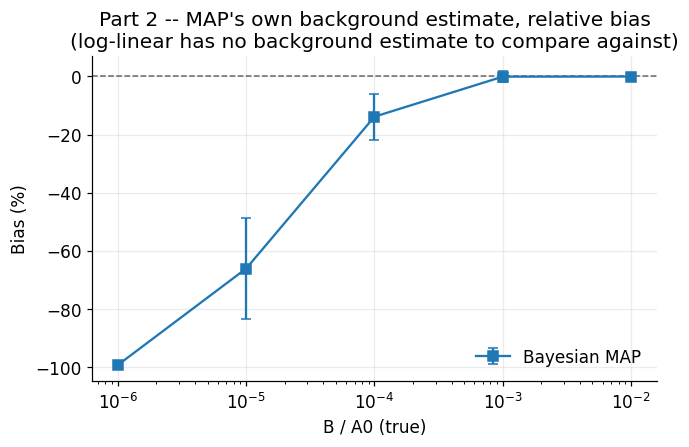

In [14]:
b_only = part2_summary[part2_summary["param"] == "B"]
fig, ax = plt.subplots(figsize=(6.2, 4.2))
ax.errorbar(
    b_only["b_ratio"], b_only["bias_pct"], yerr=b_only["bias_sem_pct"],
    marker="s", color=COLOR_MAP, label="Bayesian MAP", capsize=3, lw=1.5, markersize=6,
)
ax.axhline(0.0, color="0.4", lw=1, ls="--")
ax.set_xscale("log")
ax.set_xlabel("B / A0 (true)")
ax.set_ylabel("Bias (%)")
ax.set_title("Part 2 -- MAP's own background estimate, relative bias\n"
              "(log-linear has no background estimate to compare against)")
ax.legend(frameon=False)
fig.tight_layout()
plt.show()


In [15]:
print("Part 2 summary (bias magnitude, log-linear vs MAP):")
for param, label in [("A0", "A0"), ("t12", "half-life")]:
    sub = part2_summary[part2_summary["param"] == param]
    ll = sub[sub["estimator"] == "ll"].set_index("b_ratio")["bias_pct"]
    mp = sub[sub["estimator"] == "map"].set_index("b_ratio")["bias_pct"]
    cov_ll = sub[sub["estimator"] == "ll"].set_index("b_ratio")["coverage"]
    print(f"  {label}:")
    for r in B_RATIOS:
        print(f"    B/A0={r:.0e}: log-linear bias={ll[r]:+6.2f}% (coverage={cov_ll[r]:.2f})  "
              f"MAP bias={mp[r]:+6.2f}%")


Part 2 summary (bias magnitude, log-linear vs MAP):
  A0:
    B/A0=1e-02: log-linear bias=-38.30% (coverage=0.00)  MAP bias= +0.01%
    B/A0=1e-03: log-linear bias=-11.99% (coverage=0.00)  MAP bias= -0.09%
    B/A0=1e-04: log-linear bias= -1.62% (coverage=0.00)  MAP bias= -0.08%
    B/A0=1e-05: log-linear bias= -0.17% (coverage=0.00)  MAP bias= -0.11%
    B/A0=1e-06: log-linear bias= -0.02% (coverage=1.00)  MAP bias= -0.02%
  half-life:
    B/A0=1e-02: log-linear bias=+46.21% (coverage=0.00)  MAP bias= +0.01%
    B/A0=1e-03: log-linear bias= +7.73% (coverage=0.00)  MAP bias= -0.00%
    B/A0=1e-04: log-linear bias= +0.90% (coverage=0.00)  MAP bias= +0.09%
    B/A0=1e-05: log-linear bias= +0.09% (coverage=0.00)  MAP bias= +0.06%
    B/A0=1e-06: log-linear bias= +0.01% (coverage=0.53)  MAP bias= +0.01%


## Conclusions

The numbers below are read directly off the tables/plots produced above (all
Monte Carlo settings -- `T_MES_RATIOS`, `B_RATIOS`, `N_REP_1`, `N_REP_2`,
`FIT_CONFIG` -- are plain variables in the code cells and can be edited to
re-run with more repetitions or different values; re-running will shift the
exact figures quoted here).

**Part 1 (background = 0, varying measurement time)**: contrary to the initial
hypothesis motivating this notebook, the Bayesian MAP estimator did **not** show
a meaningfully smaller bias or RMSE than the plain log-linear regression at any
measurement time tested, from 0.1 to 10 half-lives -- both stayed under ~0.1%
bias throughout. This makes sense in hindsight: `loglinear_fit`'s only
structural weakness relative to MAP is that it never estimates background (see
its docstring), and with the true background fixed at exactly 0 in Part 1, that
weakness is simply never engaged. The one place MAP did *not* match
log-linear was empirical CI coverage at the shortest measurement time, where it
ran visibly under the nominal 95% -- attributed to the prior's centre being
the (also noisy) log-linear point estimate itself, discussed after Part 1's
coverage plot.

**Part 2 (measurement time = 10 x T1/2, varying true background)**: here the
two estimators diverge sharply, exactly as expected from `loglinear_fit` never
estimating B. At B/A0 = 10<sup>-2</sup> (background comparable to the decayed
signal), log-linear's bias was roughly -38% on A0 and +46% on the half-life,
with essentially 0% empirical coverage of its own 95% CI -- a badly broken
result. MAP's bias stayed within about 0.1% at every background level tested,
including this most extreme one, correctly recovering a background it was never
told the true value of.

**Bottom line**: for this scenario, the Bayesian MAP estimator's advantage over
a plain log-linear fit comes specifically from handling a non-negligible
background, not from measurement duration on its own. A practitioner deciding
between the two methods should weigh how confident they are that background is
genuinely negligible for their measurement, rather than assuming a fuller
statistical model is automatically better simply because it is fuller.

### Possible follow-ups
- Repeat with the paralyzable dead-time model (`DEAD_TIME_MODEL = "paralyzable"`).
- Extend to other short-lived DDEP-evaluated nuclides for comparison.
- Increase `N_REP_1`/`N_REP_2` and/or `FIT_CONFIG`'s `n_vis`/`n_is_samples` back
  toward the library's defaults for a less noisy, higher-resolution study (at the
  cost of a much longer run time).
- Investigate the short-measurement-time coverage gap noted in Part 1 -- e.g. by
  widening `Priors.prior_widen_k` further, or using a flatter prior, to see how
  much of it is attributable to the prior's data-centred construction.
